## [1] Load Clean Data

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean/clean_data.csv")
print("Shape:", df.shape)

Shape: (41872, 18)


## [2] Descriptive Statistics

In [88]:
# Numeric columns
print("=== Numeric Statistics ===")
print(df.describe().T[['mean', '50%', 'std']])

# Categorical columns
print("\n=== Categorical Frequencies ===")
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 
            'Type_of_order', 'City', 'Festival']
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).round(3))

=== Numeric Statistics ===
                                  mean        50%       std
Delivery_person_Age          29.570978  30.000000  5.642124
Delivery_person_Ratings       4.636767   4.700000  0.308471
Restaurant_latitude          18.913696  19.065838  5.467265
Restaurant_longitude         76.921664  76.618203  3.503107
Delivery_location_latitude   18.977356  19.124049  5.469056
Delivery_location_longitude  76.985325  76.662620  3.503260
Vehicle_condition             1.018891   1.000000  0.835179
multiple_deliveries           0.750979   1.000000  0.567156
Delivery_Time_min            26.315891  26.000000  9.383528

=== Categorical Frequencies ===

Weatherconditions:
Weatherconditions
Fog           0.179
Stormy        0.167
Cloudy        0.166
Sandstorms    0.165
Windy         0.163
Sunny         0.161
Name: proportion, dtype: float64

Road_traffic_density:
Road_traffic_density
Low       0.350
Jam       0.311
Medium    0.241
High      0.097
Name: proportion, dtype: float64

Type_of

## [3] Target Distribution

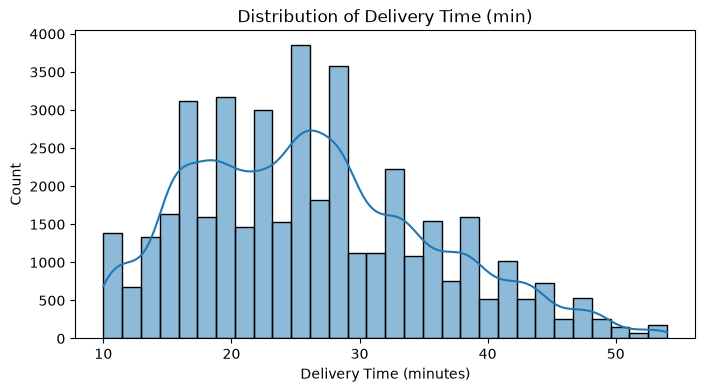

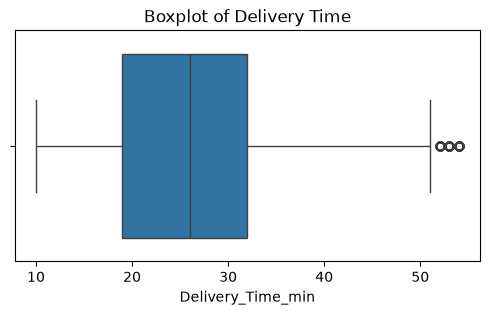

0.25    19.0
0.50    26.0
0.75    32.0
Name: Delivery_Time_min, dtype: float64

In [89]:
plt.figure(figsize=(8,4))
sns.histplot(df['Delivery_Time_min'], bins=30, kde=True)
plt.title("Distribution of Delivery Time (min)")
plt.xlabel("Delivery Time (minutes)")
plt.show()


plt.figure(figsize=(6,3))
sns.boxplot(x=df['Delivery_Time_min'])
plt.title("Boxplot of Delivery Time")
plt.show()

df["Delivery_Time_min"].median()
df["Delivery_Time_min"].quantile([0.25, 0.50, 0.75])

Analyse de la distribution de la variable cible :
La distribution des temps de livraison s'étend approximativement de 10 à 55 minutes. La majorité des observations se situe entre 15 et 35 minutes, avec une concentration importante autour de 20 à 30 minutes. La distribution présente une légère asymétrie vers la droite, avec quelques temps de livraison plus élevés. Le boxplot indique une médiane située autour de 26 minutes et met en évidence quelques valeurs potentiellement aberrantes au-delà d'environ 52 minutes. Ces observations seront examinées avant de décider de leur traitement.

## [4] Create Feature Distance in kilometers

In [90]:
if "Distance_km" not in df.columns:

    earth_radius_km = 6371

    lat1 = np.radians(df["Restaurant_latitude"])
    lon1 = np.radians(df["Restaurant_longitude"])

    lat2 = np.radians(df["Delivery_location_latitude"])
    lon2 = np.radians(df["Delivery_location_longitude"])

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2) ** 2
    )

    a = np.clip(a, 0, 1)

    df["Distance_km"] = (
        2 * earth_radius_km * np.arcsin(np.sqrt(a))
    )

print(df["Distance_km"].describe())

count    41872.000000
mean         9.719296
std          5.602890
min          1.465067
25%          4.657655
50%          9.193014
75%         13.680920
max         20.969489
Name: Distance_km, dtype: float64


## [5] Relationship with Numeric Features
#### 1_ Distance_km vs Delivery Time
Distance alone does not strongly predict delivery time. A short 2 km trip can take 50 minutes (likely due to heavy traffic or slow food preparation), while a long 18 km trip can sometimes take only 15 minutes

#### 2_ multiple_deliveries vs Delivery Time: 
0 or 1 delivery: Deliveries can be super fast (starting down at 10 minutes).   
2 deliveries: Minimum time jumps up to around 30 minutes.   
3 deliveries: Minimum time jumps even higher to 40+ minutes.

#### 3_ Delivery_person_Ratings vs Delivery Time
Higher ratings equal faster deliveries: Couriers rated 4.0 to 5.0 are the only ones delivering orders in 10 to 30 minutes. Low-rated couriers (below 4.0) never complete fast deliveries and generally take 30+ minutes.

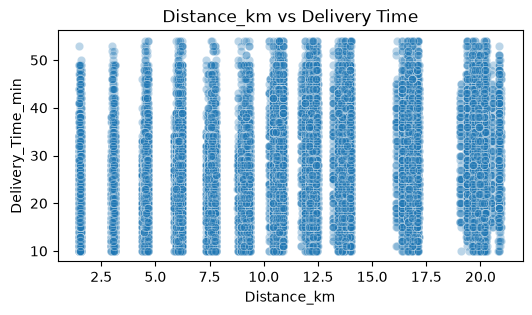

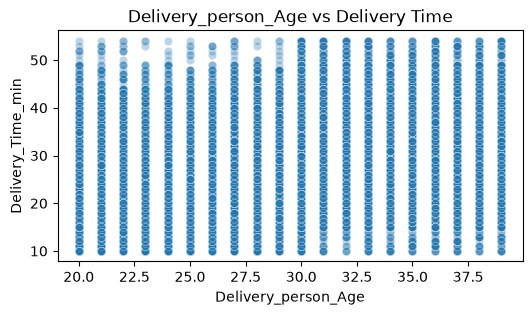

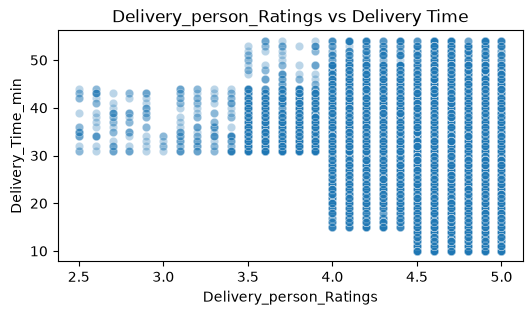

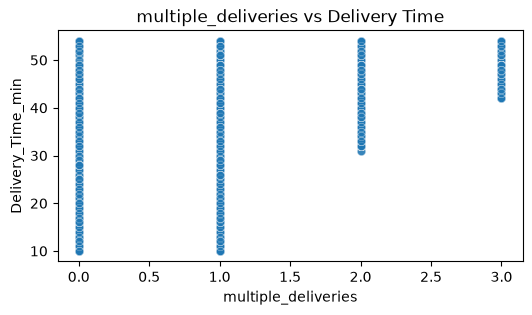

In [91]:
num_features = ['Distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings', 
                 'multiple_deliveries']

for col in num_features:
    plt.figure(figsize=(6,3))
    sns.scatterplot(x=df[col], y=df['Delivery_Time_min'], alpha=0.3)
    plt.title(f"{col} vs Delivery Time")
    plt.show()

##  [6] Relationship with Categorical Features

#### 1_Weather conditions vs Delivery Time
Sunny weather yields the fastest deliveries ($\approx 20\text{ min}$ median). Adverse weather like Cloudy or Fog delays deliveries ($\approx 28\text{--}29\text{ min}$ median). 

#### 2_ Road traffic density vs Delivery Time
Low traffic results in the lowest delivery times ($\approx 21\text{ min}$ median). Traffic jams cause significant delays, pushing median delivery times up to $31\text{ min}$. 

#### 3_ Type of vehicle vs Delivery Time
Scooters and electric scooters are slightly faster ($\approx 24\text{ min}$ median) compared to motorcycles and bicycles ($\approx 26\text{--}28\text{ min}$ median).

#### 4_ City vs Delivery Time:
Urban areas have the fastest deliveries ($\approx 22\text{ min}$ median). Semi-Urban areas suffer heavy delays, averaging around $49\text{ min}$ per delivery


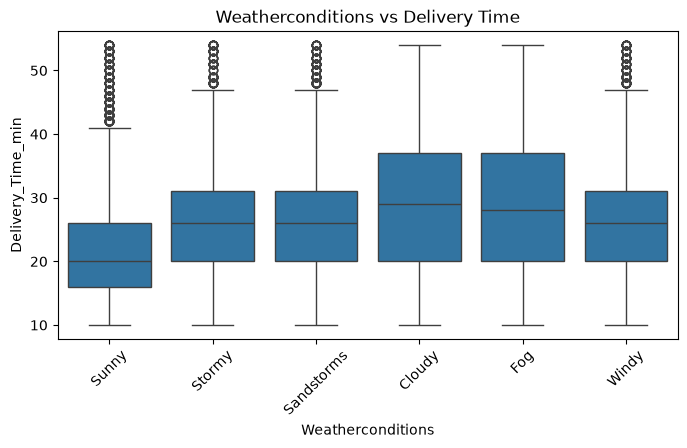

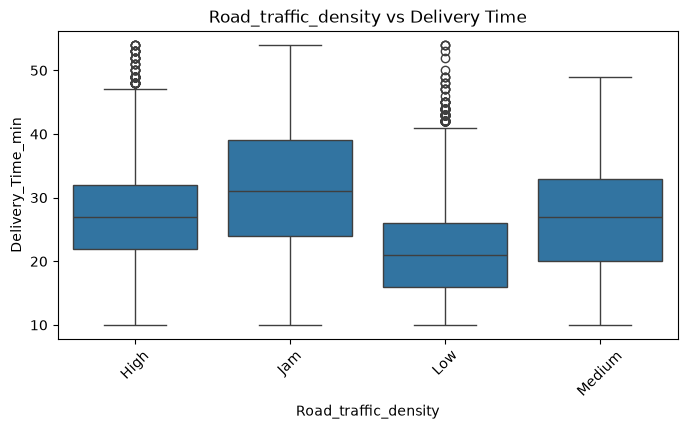

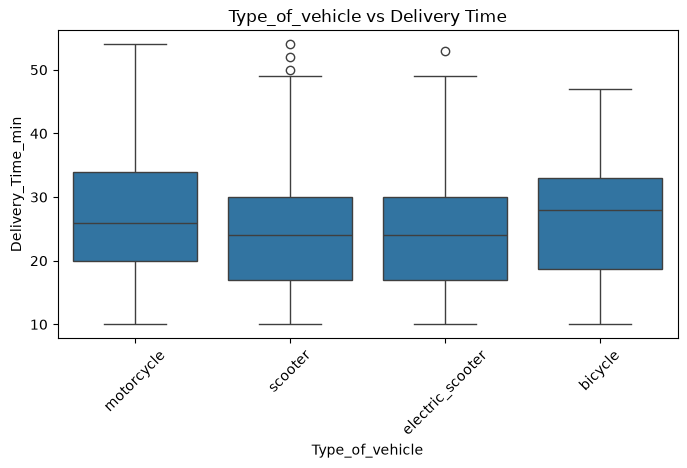

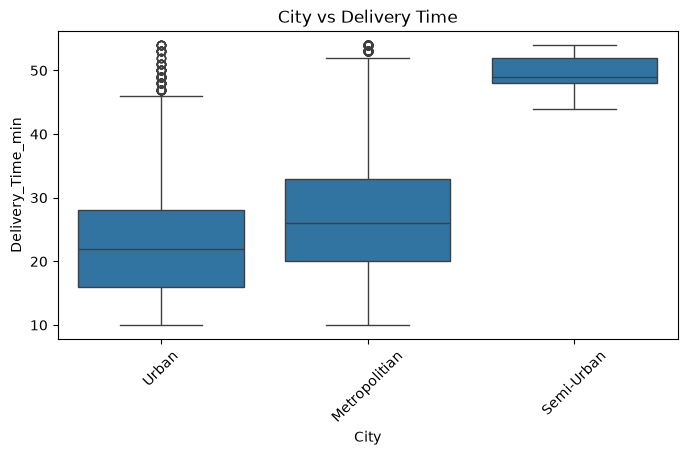

In [92]:
cat_features = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'City']

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['Delivery_Time_min'])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Delivery Time")
    plt.show()

##  [7] Correlation Matrix

#### 1_ multiple_deliveries
(+0.38): Strongest positive factor. Carrying more orders at once increases the delivery time significantly

#### 2_ Delivery_person_Ratings
(-0.35): Strongest negative factor. Higher-rated couriers take less time to complete deliveries.

#### 3_ Distance_km
(+0.32): Longer distances lead to longer delivery times.

#### 4_ Delivery_person_Age
(+0.30): Older delivery persons tend to have slightly longer delivery times in this dataset.

#### 5_ Vehicle_condition
(-0.24): Better vehicle condition (higher score) leads to faster deliveries.


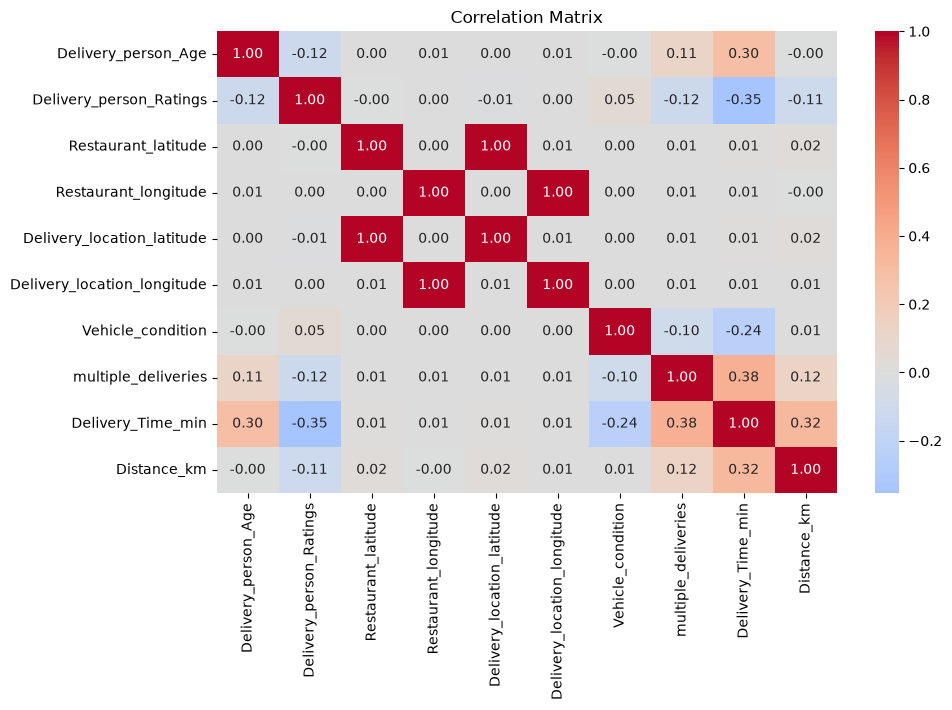

In [93]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## [8]  Feature Engineering

In [94]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

df["Order_Hour"] = df["Time_Orderd"].dt.hour

df["Is_Weekend"] = (
    pd.to_datetime(df["Order_Date"]).dt.dayofweek.isin([5, 6])
).astype(int)

print(df[[
    "Time_Orderd",
    "Distance_km",
    "Order_Hour",
    "Is_Weekend"
]].head())

          Time_Orderd  Distance_km  Order_Hour  Is_Weekend
0 1900-01-01 11:30:00     3.025149          11           1
1 1900-01-01 19:45:00    20.183530          19           0
2 1900-01-01 08:30:00     1.552758           8           1
3 1900-01-01 18:00:00     7.790401          18           0
4 1900-01-01 13:30:00     6.210138          13           1


## [9] redundant columns

In [95]:
cols_to_drop = [
    'Restaurant_latitude', 'Restaurant_longitude', 
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'Order_Date', 'Time_Orderd', 'Time_Order_picked'
]

# drop
df_model = df.drop(columns = [col for col in cols_to_drop if col in df.columns])
# save
df_model.to_csv("../data/clean/model_ready_data.csv",index= False)
print('(------------------- Saved ---------------)')
print(df_model.columns.tolist())


(------------------- Saved ---------------)
['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Delivery_Time_min', 'Distance_km', 'Order_Hour', 'Is_Weekend']
